# 01 - LV Scar Exploration

Focus: Core Zone (CZ) only.

Pipeline:
1. Scan + EDA
2. 80/20 split
3. 3-D visualisation (aligned overlay + grid)
4. 2-D polar maps + superposition
5. ISOMAP shape analysis

## 0 - Imports & config

In [1]:
import json, random, sys
from dataclasses import dataclass, field
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from scipy.spatial.distance import cdist
from sklearn.manifold import Isomap
from tqdm import tqdm

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
from data_loading import scan, diagnose, PatientCase

HD_ROOT          = r"F:/RM_TEKNON_DEVELOP"
SEED             = 42
TRAIN_RATIO      = 0.80
N_R              = 64
N_THETA          = 128
GRID3D_MAX       = 24
ISOMAP_PTS       = 800
ISOMAP_K         = 10
MIN_VERTS_ISOMAP = 5

USE_PROXY        = True   # True: CZ for those who have it + power_paths for the rest
                         # False: only real CZ cases

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

pv.set_jupyter_backend("static")
plt.rcParams["figure.dpi"] = 120


## 1 - Scan & EDA

In [2]:
all_cases = scan(HD_ROOT)

def has_cz(c):
    p = c.tissue_surfaces.get("core")
    return p is not None and p.exists()

def has_proxy(c):
    p = c.tissue_surfaces.get("power_paths")
    return p is not None and p.exists()

def get_cz_mesh(c):
    """Return the CZ mesh for a case: real CZ if available, filled proxy otherwise."""
    if has_cz(c):
        return pv.read(str(c.tissue_surfaces["core"]))
    if USE_PROXY and has_proxy(c):
        pp = pv.read(str(c.tissue_surfaces["power_paths"]))
        return fill_power_paths(pp)
    return None

if USE_PROXY:
    valid = [c for c in all_cases if has_cz(c) or has_proxy(c)]
else:
    valid = [c for c in all_cases if has_cz(c)]

print(f"USE_PROXY        : {USE_PROXY}")
print(f"Total scanned    : {len(all_cases)}")
print(f"Real CZ          : {sum(1 for c in all_cases if has_cz(c))}")
print(f"Proxy only       : {sum(1 for c in all_cases if not has_cz(c) and has_proxy(c))}")
print(f"Valid (this run) : {len(valid)}")


### 1a - EDA: dataset overview

In [3]:
c1,c2,c3,c4,c5,c6 = "Year","Total","Has LV","Has CZ","Has Proxy","CZ+Proxy"
print(f"{c1:<6} {c2:>7} {c3:>8} {c4:>8} {c5:>11} {c6:>10}")
print("-" * 54)
for year in sorted(set(c.year for c in all_cases)):
    yc    = [c for c in all_cases if c.year == year]
    n_lv  = sum(1 for c in yc if c.lv_dir is not None)
    n_cz  = sum(1 for c in yc if has_cz(c))
    n_pp  = sum(1 for c in yc if not has_cz(c) and has_proxy(c))
    n_any = sum(1 for c in yc if has_cz(c) or has_proxy(c))
    print(f"{year:<6} {len(yc):>7} {n_lv:>8} {n_cz:>8} {n_pp:>11} {n_any:>10}")
print("-" * 54)
tot       = "TOTAL"
total_cz  = sum(1 for c in all_cases if has_cz(c))
total_pp  = sum(1 for c in all_cases if not has_cz(c) and has_proxy(c))
total_any = total_cz + total_pp
blank     = ""
print(f"{tot:<6} {len(all_cases):>7} {blank:>8} {total_cz:>8} {total_pp:>11} {total_any:>10}")


Year     Total   Has LV   Has CZ   Has Proxy   CZ+Proxy
------------------------------------------------------
2021        12       12       12           0         12
2022        27       23       10          12         22
2023        47       45       18          15         33
2024        31       31        0          28         28
2025         7        7        0           7          7
------------------------------------------------------
TOTAL      124                40          62        102


### 1b - Diagnostic: TISSUE contents for cases WITHOUT CZ

Run this to see what files are actually on disk.

In [4]:
no_cz = [c for c in all_cases if c.lv_dir is not None and c.tissue_surfaces.get("core") is None]
print(f"Cases with LV dir but no CZ matched: {len(no_cz)}")
for case in no_cz[:5]:
    diagnose(case)


Cases with LV dir but no CZ matched: 78

------------------------------------------------------------
Patient : 2022/02016806
LV dir  : F:\RM_TEKNON_DEVELOP\2022\02016806\Basal\Data\DE-MRI 3D\LV

  TISSUE/ contains 19 VTK files (recursive):
    3D Corridor 3D Border Zone.vtk
    3D Corridor Border Zone on Layer.vtk
    3D Corridor Centerlines.vtk
    3D Corridor Filtered Centerlines.vtk
    3D Corridor Labels.vtk
    3D Corridor Mask Image.vtk
    3D Corridor Unified Centerlines Tubes.vtk
    3D Corridor Unified Centerlines.vtk
    Automatic 3D Corridors.vtk
    Layer_10.vtk
    Layer_20.vtk
    Layer_30.vtk
    Layer_40.vtk
    Layer_50.vtk
    Layer_60.vtk
    Layer_70.vtk
    Layer_80.vtk
    Layer_90.vtk
    PowerPaths.vtk

  Resolved tissue_surfaces:
    core         -> NOT FOUND
    border_zone  -> 3D Corridor 3D Border Zone.vtk
    healthy      -> NOT FOUND
    scar         -> NOT FOUND
    power_paths  -> PowerPaths.vtk
----------------------------------------------------------

### 1c - Power Paths fill diagnostic

Power paths are line contours (Case A). This cell tests the fill
strategy on one sample case and renders the result.

Cases with power_paths: 101
Trying 2021/02026677
  n_points=889  n_cells=889
  22 loop(s) found
  Filled OK: n_faces_strict=1107


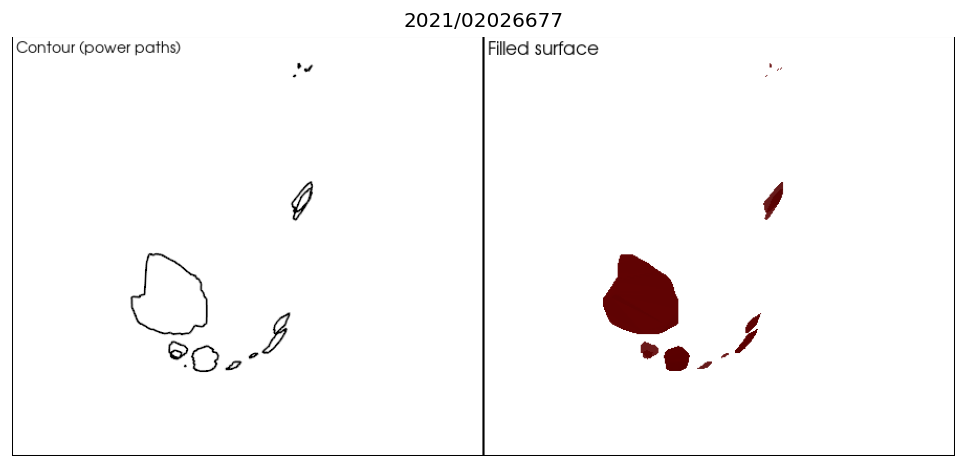

In [5]:
import pyvista as pv
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.csgraph import connected_components

def fill_power_paths(pp_mesh, alpha_factor=0.8):
    """Fill line-contour power paths into a triangulated surface.

    alpha is set per loop as alpha_factor * bounding-box diagonal.
    Since loops have no interior points, alpha must span the full
    loop width - much larger than point spacing.
    alpha_factor < 1.0 keeps loops separate; > 1.0 may bridge gaps.
    """
    pts = np.array(pp_mesh.points)
    if len(pts) < 3:
        return None
    # Build adjacency from line cells
    n = len(pts)
    adj = lil_matrix((n, n), dtype=np.int8)
    cells = np.array(pp_mesh.lines)
    idx = 0
    while idx < len(cells):
        seg_len = int(cells[idx])
        if seg_len == 2:
            p0, p1 = int(cells[idx+1]), int(cells[idx+2])
            adj[p0, p1] = 1
            adj[p1, p0] = 1
        idx += seg_len + 1
    # Connected components = one per closed loop
    n_comp, labels = connected_components(adj.tocsr(), directed=False)
    print(f"  {n_comp} loop(s) found")
    # Fill each loop independently
    patches = []
    for cid in range(n_comp):
        loop_pts = pts[labels == cid]
        if len(loop_pts) < 3:
            continue
        # alpha = fraction of bounding-box diagonal (spans the interior)
        bbox_diag = float(np.linalg.norm(loop_pts.max(axis=0) - loop_pts.min(axis=0)))
        alpha = bbox_diag * alpha_factor
        try:
            patch = pv.PolyData(loop_pts).delaunay_2d(alpha=alpha)
            if patch.n_faces_strict > 0:
                patches.append(patch)
        except Exception as e:
            print(f"  loop {cid}: delaunay failed ({e})")
    if not patches:
        return None
    merged = patches[0]
    for p in patches[1:]:
        merged = merged.merge(p)
    return merged

pp_cases = [c for c in all_cases if c.tissue_surfaces.get("power_paths") is not None]
print(f"Cases with power_paths: {len(pp_cases)}")

test_case = pp_mesh = filled = None
for case in pp_cases[:5]:
    print(f"Trying {case.year}/{case.patient_id}")
    m = pv.read(str(case.tissue_surfaces["power_paths"]))
    print(f"  n_points={m.n_points}  n_cells={m.n_cells}")
    f = fill_power_paths(m)
    if f is not None:
        print(f"  Filled OK: n_faces_strict={f.n_faces_strict}")
        test_case, pp_mesh, filled = case, m, f
        break
    print("  Fill failed")

if filled is not None:
    pl = pv.Plotter(shape=(1, 2), off_screen=True, window_size=(900, 400))
    pl.subplot(0, 0)
    pl.add_text("Contour (power paths)", font_size=8)
    pl.add_mesh(pp_mesh, color="black", line_width=2, render_lines_as_tubes=True)
    pl.set_background("white")
    pl.reset_camera()
    pl.subplot(0, 1)
    pl.add_text("Filled surface", font_size=8)
    pl.add_mesh(filled, color="red", opacity=0.9)
    pl.set_background("white")
    pl.reset_camera()
    img = pl.screenshot(None, return_img=True)
    pl.close()
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{test_case.year}/{test_case.patient_id}")
    plt.tight_layout()
    plt.show()
else:
    print("All 5 cases failed.")

## 2 - 80/20 split

In [6]:
random.seed(SEED)
shuffled = random.sample(valid, len(valid))
n_known  = int(len(shuffled) * TRAIN_RATIO)
known    = shuffled[:n_known]
held_out = shuffled[n_known:]

(RESULTS / "split.json").write_text(json.dumps({
    "seed": SEED, "train_ratio": TRAIN_RATIO,
    "known":    [f"{c.year}/{c.patient_id}" for c in known],
    "held_out": [f"{c.year}/{c.patient_id}" for c in held_out],
}, indent=2))
print(f"Known: {len(known)}   Held-out: {len(held_out)}")


Known: 81   Held-out: 21


## 3 - 3-D visualisation

Each render: Left Ventricle shell (semi-transparent) + CZ (opaque red).

For the overlay all LV meshes are aligned before stacking:
- apex translated to origin
- long axis rotated to Z (all hearts point the same way)

This makes the population view meaningful: you can see which LV regions tend to carry CZ scar.

In [7]:
def _best_shell(case):
    """Left Ventricle > Myocardium > Endo > Epi."""
    for key in ("lv", "myocardium", "endo", "epi"):
        p = case.anatomy.get(key)
        if p is not None and p.exists():
            return pv.read(str(p))
    return None


def _compute_transform(lv_mesh):
    """Returns (R, apex) so that (pts - apex) @ R.T puts apex at origin, long axis along +Z."""
    pts    = np.array(lv_mesh.points)
    center = pts.mean(axis=0)
    _, _, Vt = np.linalg.svd(pts - center, full_matrices=False)
    axis   = Vt[0]
    proj   = (pts - center) @ axis
    apex   = pts[proj.argmin()]
    if np.dot(center - apex, axis) < 0:
        axis = -axis
    z  = np.array([0., 0., 1.])
    v  = np.cross(axis, z)
    s  = np.linalg.norm(v)
    c  = np.dot(axis, z)
    if s < 1e-9:
        R = np.eye(3)
    else:
        vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
        R  = np.eye(3) + vx + vx @ vx * ((1 - c) / (s ** 2))
    return R, apex


def _apply_transform(mesh, R, apex):
    m = mesh.copy()
    m.points = (np.array(mesh.points) - apex) @ R.T
    return m

print("3-D helpers ready.")


3-D helpers ready.


### 3b - Per-patient 3-D grid (first GRID3D_MAX cases)

In [9]:
subset   = known[:GRID3D_MAX]
ncols_3d = 6
nrows_3d = int(np.ceil(len(subset) / ncols_3d))

thumbnails = []
for case in tqdm(subset, desc="3-D grid"):
    try:
        cz = get_cz_mesh(case)
        if cz is None:
            continue
        pl = pv.Plotter(off_screen=True, window_size=(300, 260))
        pl.set_background("#1e1e1e")
        shell = _best_shell(case)
        if shell is not None:
            pl.add_mesh(shell, color="lightgray", opacity=0.15,
                        smooth_shading=True, show_scalar_bar=False)
        pl.add_mesh(cz, color="crimson", opacity=0.95,
                    smooth_shading=True, show_scalar_bar=False)
        pl.view_isometric()
        thumbnails.append((case, pl.screenshot(None, return_img=True)))
        pl.close()
    except Exception as e:
        print(f"  skip {case.year}/{case.patient_id}: {e}")

fig, axes = plt.subplots(nrows_3d, ncols_3d, figsize=(ncols_3d * 2.2, nrows_3d * 2),
                         squeeze=False)
fig.suptitle(f"3-D per-patient grid - {len(thumbnails)} cases (USE_PROXY={USE_PROXY})", fontsize=12)
axes_flat = axes.ravel()
for ax in axes_flat:
    ax.axis("off")
for ax, (case, img) in zip(axes_flat, thumbnails):
    ax.imshow(img)
    src = "CZ" if has_cz(case) else "proxy"
    ax.set_title(f"{case.year}
{case.patient_id}
[{src}]", fontsize=6)
plt.tight_layout()
plt.savefig(RESULTS / "3d_grid_known.png", bbox_inches="tight")
plt.show()


## 4 - 2-D cylindrical polar projection

How it works:
1. PCA on the LV shell finds the long axis (apex to base).
2. Each CZ vertex gets s (distance along axis from apex, 0-1) and theta (angle around axis, 0-360 deg).
3. Rasterise onto an (N_R x N_THETA) binary grid.
4. Plot as bull's-eye: apex at centre, base at outer ring.

Known limitation: the apex is a dome so apical scars appear spread over the inner disc.
Use ISOMAP (Section 5) for faithful shape analysis.

In [10]:
def _long_axis(mesh):
    pts    = np.array(mesh.points)
    center = pts.mean(axis=0)
    _, _, Vt = np.linalg.svd(pts - center, full_matrices=False)
    axis   = Vt[0]
    proj   = (pts - center) @ axis
    apex   = pts[proj.argmin()]
    if np.dot(center - apex, axis) < 0:
        axis = -axis
    return axis, apex


def polar_map(case, n_r=N_R, n_theta=N_THETA):
    ref = _best_shell(case)
    if ref is None:
        ref = pv.read(str(case.tissue_surfaces["core"]))
    axis, apex = _long_axis(ref)
    secondary = np.array([0., 0., 1.])
    if abs(np.dot(axis, secondary)) > 0.9:
        secondary = np.array([1., 0., 0.])
    u = np.cross(axis, secondary); u /= np.linalg.norm(u)
    w = np.cross(axis, u)
    cz    = pv.read(str(case.tissue_surfaces["core"]))
    pts   = np.array(cz.points)
    v     = pts - apex
    s_raw = v @ axis
    span  = s_raw.max() - s_raw.min()
    s     = np.clip((s_raw - s_raw.min()) / (span + 1e-9), 0., 1.)
    perp  = v - np.outer(s_raw, axis)
    theta = np.arctan2(perp @ w, perp @ u) % (2 * np.pi)
    grid  = np.zeros((n_r, n_theta), dtype=bool)
    ri    = np.clip((s * n_r).astype(int), 0, n_r - 1)
    ti    = np.clip((theta / (2*np.pi) * n_theta).astype(int), 0, n_theta - 1)
    grid[ri, ti] = True
    return grid


def _draw_bullseye(grid, ax, title="", cmap="Reds", vmax=1.):
    n_r, n_theta = grid.shape
    T, R = np.meshgrid(np.linspace(0, 2*np.pi, n_theta+1), np.linspace(0, 1, n_r+1))
    ax.pcolormesh(T, R, grid.astype(float), cmap=cmap, vmin=0, vmax=vmax, shading="flat")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rticks([]); ax.set_xticks([])
    if title:
        ax.set_title(title, fontsize=7, pad=2)

print("Polar map helpers ready.")


Polar map helpers ready.


### 4a - Compute polar maps

In [11]:
pmaps = {}
for case in tqdm(known, desc="Polar projection"):
    key = f"{case.year}/{case.patient_id}"
    try:
        pmaps[key] = polar_map(case)
    except Exception as e:
        print(f"  skip {key}: {e}")
print(f"OK: {len(pmaps)}")


Polar projection:   7%|▋         | 6/81 [00:00<00:01, 56.15it/s]

  skip 2024/50091035: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2022/11003916: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2024/50147423: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2022/18002857: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2022/10008145: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2024/50101842: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found


Polar projection:  15%|█▍        | 12/81 [00:00<00:01, 57.85it/s]

  skip 2024/02039103: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found


Polar projection:  23%|██▎       | 19/81 [00:00<00:01, 59.66it/s]

...

  skip 2024/50101361: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2023/96024662: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2024/02027088: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2022/18030390: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2022/02016806: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2024/50102536: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found


Polar projection:  93%|█████████▎| 75/81 [00:01<00:00, 64.93it/s]

  skip 2023/50088992: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2025/50147172: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2024/19014762: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2024/15026033: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2023/96011287: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2025/18049097: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2023/50057305: 

Polar projection: 100%|██████████| 81/81 [00:01<00:00, 62.10it/s]

  skip 2023/99008482: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
OK: 31


### 4b - Individual polar maps (per-patient grid)

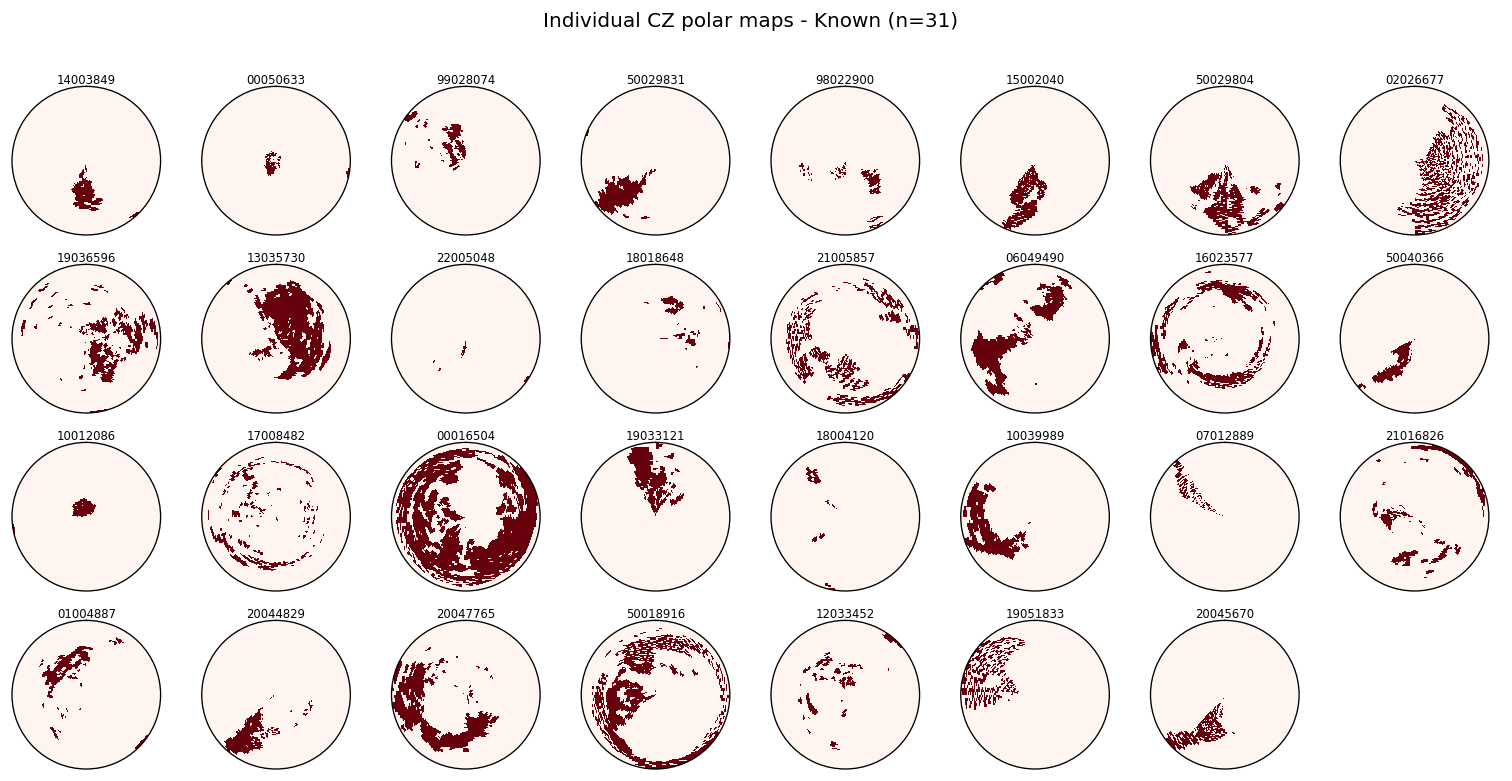

In [12]:
if not pmaps:
    print("No polar maps - check scan.")
else:
    keys  = list(pmaps.keys())
    ncols = 8
    nrows = int(np.ceil(len(keys) / ncols))
    fig   = plt.figure(figsize=(ncols*1.6, nrows*1.6))
    fig.suptitle(f"Individual CZ polar maps - Known (n={len(keys)})", fontsize=12, y=1.01)
    for idx, key in enumerate(keys):
        ax = fig.add_subplot(nrows, ncols, idx+1, projection="polar")
        _draw_bullseye(pmaps[key], ax, title=key.split("/")[1])
    for idx in range(len(keys), nrows*ncols):
        fig.add_subplot(nrows, ncols, idx+1).axis("off")
    plt.tight_layout()
    plt.savefig(RESULTS / "polar_grid_known.png", bbox_inches="tight")
    plt.show()


### 4c - Superposition: scar density

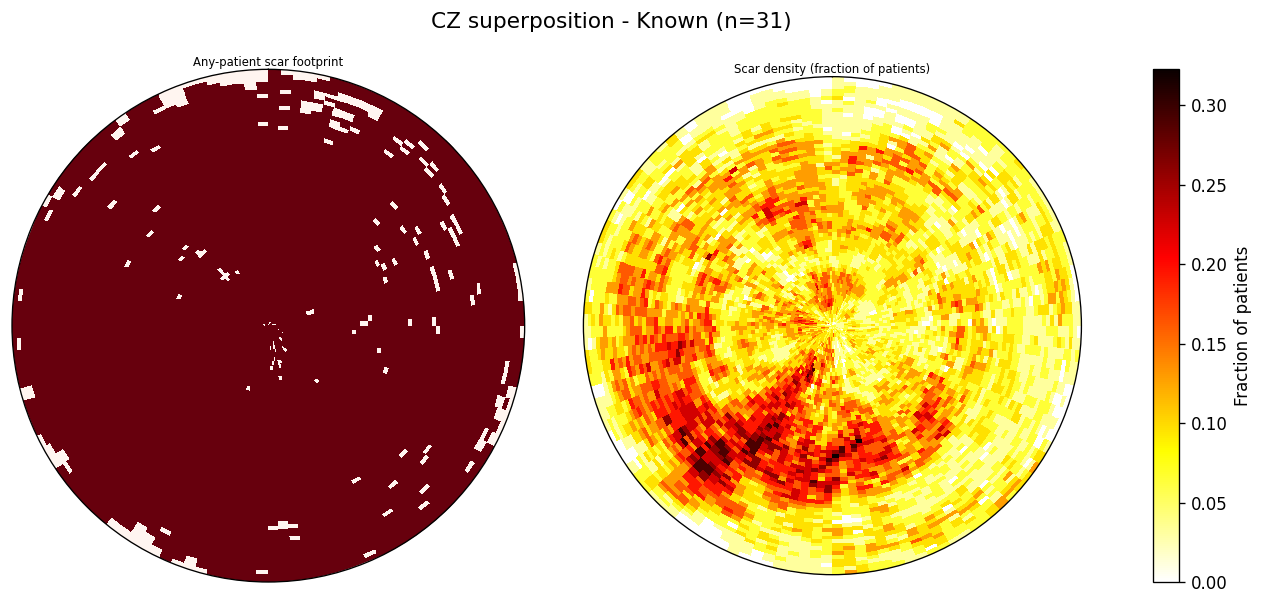

In [13]:
if not pmaps:
    print("No polar maps.")
else:
    stack   = np.stack(list(pmaps.values()))
    density = stack.mean(axis=0)
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 5), subplot_kw={"projection": "polar"})
    fig.suptitle(f"CZ superposition - Known (n={len(pmaps)})", fontsize=13)
    _draw_bullseye(density > 0, ax_l, title="Any-patient scar footprint")
    _draw_bullseye(density, ax_r, title="Scar density (fraction of patients)", cmap="hot_r", vmax=density.max())
    sm = plt.cm.ScalarMappable(cmap="hot_r", norm=plt.Normalize(0, density.max()))
    sm.set_array([])
    fig.colorbar(sm, ax=ax_r, pad=0.12, fraction=0.046, label="Fraction of patients")
    plt.tight_layout()
    plt.savefig(RESULTS / "polar_superposition_known.png", bbox_inches="tight")
    plt.show()


## 5 - ISOMAP shape analysis

| Situation | Action |
|---|---|
| 1 fragment | ISOMAP on all vertices |
| N fragments | ISOMAP on each fragment separately + fragmentation features |

Why per-fragment: geodesic distances between disconnected islands are infinite.
Running ISOMAP independently per fragment avoids a corrupted distance matrix.

Fragments with fewer than MIN_VERTS_ISOMAP vertices are counted but not embedded.

Future note: tiny sub-scars could be filtered by area or vertex count. For now all are kept.

In [14]:
@dataclass
class CZAnalysis:
    key:                  str
    n_fragments:          int
    vertex_counts:        list
    largest_fraction:     float
    centroids:            np.ndarray
    centroid_dist_matrix: np.ndarray
    embeddings:           list

    @property
    def is_compact(self):
        return self.n_fragments == 1


def _run_isomap(pts, k=ISOMAP_K, n_pts=ISOMAP_PTS):
    if len(pts) > n_pts:
        idx = np.random.default_rng(SEED).choice(len(pts), n_pts, replace=False)
        pts = pts[idx]
    k_actual = min(k, len(pts) - 1)
    return Isomap(n_neighbors=k_actual, n_components=2).fit_transform(pts)


def analyze_cz(case):
    key     = f"{case.year}/{case.patient_id}"
    cz      = pv.read(str(case.tissue_surfaces["core"]))
    labeled = cz.connectivity(largest=False)
    n_frags = int(labeled["RegionId"].max()) + 1
    reg_ids = np.array(labeled["RegionId"])
    all_pts = np.array(labeled.points)
    frag_indices = sorted(range(n_frags),
                          key=lambda i: np.sum(reg_ids == i), reverse=True)
    vertex_counts, centroids, embeddings = [], [], []
    for fid in frag_indices:
        mask = reg_ids == fid
        pts  = all_pts[mask]
        vertex_counts.append(len(pts))
        centroids.append(pts.mean(axis=0))
        if len(pts) >= MIN_VERTS_ISOMAP:
            try:
                embeddings.append(_run_isomap(pts))
            except Exception as e:
                print(f"    ISOMAP failed {key}: {e}")
                embeddings.append(None)
        else:
            embeddings.append(None)
    centroids = np.array(centroids)
    dist_mat  = cdist(centroids, centroids) if len(centroids) > 1 else np.zeros((1, 1))
    return CZAnalysis(
        key=key, n_fragments=n_frags,
        vertex_counts=vertex_counts,
        largest_fraction=vertex_counts[0] / max(sum(vertex_counts), 1),
        centroids=centroids, centroid_dist_matrix=dist_mat, embeddings=embeddings,
    )

print("CZAnalysis helpers ready.")


CZAnalysis helpers ready.


### 5a - Run analysis on Known set

In [15]:
analyses = {}
for case in tqdm(known, desc="ISOMAP analysis"):
    key = f"{case.year}/{case.patient_id}"
    try:
        analyses[key] = analyze_cz(case)
    except Exception as e:
        print(f"  skip {key}: {e}")

compact    = [a for a in analyses.values() if a.is_compact]
fragmented = [a for a in analyses.values() if not a.is_compact]
print(f"Analysed        : {len(analyses)}")
print(f"Compact (1 frag): {len(compact)}")
print(f"Fragmented (>1) : {len(fragmented)}")


ISOMAP analysis:  15%|█▍        | 12/81 [00:00<00:00, 109.80it/s]

  skip 2024/50091035: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2022/11003916: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2021/14003849: boolean index did not match indexed array along axis 0; size of axis is 1473 but size of corresponding boolean axis is 2892
  skip 2024/50147423: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2023/00050633: boolean index did not match indexed array along axis 0; size of axis is 1222 but size of corresponding boolean axis is 2376
  skip 2022/99028074: boolean index did not match indexed array along axis 0; size of axis is 2738 but size of corresponding boolean axis is 5308
  skip 2022/50029831: boolean index did not match indexed array along axi

ISOMAP analysis:  57%|█████▋    | 46/81 [00:00<00:00, 124.20it/s]

  skip 2022/19036596: boolean index did not match indexed array along axis 0; size of axis is 10014 but size of corresponding boolean axis is 19008
  skip 2024/50113435: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2023/13035730: boolean index did not match indexed array along axis 0; size of axis is 13906 but size of corresponding boolean axis is 27736
  skip 2024/13036566: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2022/19021225: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2024/50101530: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2025/50161058: File (C:\Users\joan\Desktop\FE

ISOMAP analysis:  73%|███████▎  | 59/81 [00:00<00:00, 95.06it/s] 

  skip 2024/50101361: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2023/00016504: boolean index did not match indexed array along axis 0; size of axis is 12818 but size of corresponding boolean axis is 25484
  skip 2021/19033121: boolean index did not match indexed array along axis 0; size of axis is 4006 but size of corresponding boolean axis is 7864
  skip 2023/96024662: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2021/18004120: boolean index did not match indexed array along axis 0; size of axis is 204 but size of corresponding boolean axis is 376
  skip 2024/02027088: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2022/18030390: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar

ISOMAP analysis: 100%|██████████| 81/81 [00:00<00:00, 113.64it/s]

  skip 2023/20047765: boolean index did not match indexed array along axis 0; size of axis is 8696 but size of corresponding boolean axis is 16960
  skip 2025/18049097: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2023/50057305: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2024/19027627: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2022/50018916: boolean index did not match indexed array along axis 0; size of axis is 4528 but size of corresponding boolean axis is 9004
  skip 2023/98036665: File (C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\.claude\worktrees\charming-buck\lv-scar-segmentation\notebooks\None) not found
  skip 2023/12033452: boolean index did not match index

### 5b - ISOMAP embedding grid

- Gray border = compact (1 fragment)
- Orange border = fragmented (each fragment a different colour)
- x marker = fragment too small to embed

In [16]:
FRAG_CMAP = plt.get_cmap("tab10")

def _plot_isomap_cell(ax, analysis):
    for fi, (emb, count) in enumerate(zip(analysis.embeddings, analysis.vertex_counts)):
        color = "crimson" if analysis.is_compact else FRAG_CMAP(fi % 10)
        if emb is not None and len(emb) > 0:
            ax.scatter(emb[:, 0], emb[:, 1], s=1, c=[color], alpha=0.6, linewidths=0)
        else:
            ax.scatter([0], [0], marker="x", s=20, c=[color], linewidths=1)
    n   = analysis.n_fragments
    pid = analysis.key.split("/")[1]
    ax.set_title(f"{pid} ({n}f)" if n > 1 else pid, fontsize=6, pad=1)
    ax.set_xticks([]); ax.set_yticks([])
    try:
        ax.set_aspect("equal", adjustable="datalim")
    except Exception:
        pass
    bc = "orange" if not analysis.is_compact else "#888888"
    for sp in ax.spines.values():
        sp.set_linewidth(0.5); sp.set_color(bc)


if not analyses:
    print("No analyses available - check scan.")
else:
    ikeys = list(analyses.keys())
    ncols = 8
    nrows = max(1, int(np.ceil(len(ikeys) / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*1.8, nrows*1.8), squeeze=False)
    fig.suptitle(
        f"ISOMAP shape embeddings - Known CZ (n={len(ikeys)})  gray=compact  orange=fragmented",
        fontsize=11, y=1.01
    )
    axes_flat = axes.ravel()
    for ax in axes_flat:
        ax.axis("off")
    for ax, key in zip(axes_flat, ikeys):
        ax.axis("on")
        try:
            _plot_isomap_cell(ax, analyses[key])
        except Exception as e:
            ax.set_title(key.split("/")[1], fontsize=6)
            print(f"  plot failed {key}: {e}")
    plt.tight_layout()
    plt.savefig(RESULTS / "isomap_grid_known.png", bbox_inches="tight")
    plt.show()


No analyses available - check scan.


### 5c - Fragmentation summary

In [17]:
if not analyses:
    print("No analyses.")
else:
    n_frags_all      = [a.n_fragments      for a in analyses.values()]
    largest_frac_all = [a.largest_fraction for a in analyses.values()]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle("CZ fragmentation - Known set", fontsize=13)
    ax = axes[0]
    ax.hist(n_frags_all, bins=range(1, max(n_frags_all)+2), align="left",
            color="steelblue", edgecolor="white", rwidth=0.8)
    ax.axvline(1.5, color="orange", lw=1.5, ls="--", label="compact/fragmented")
    ax.set_xlabel("Number of fragments"); ax.set_ylabel("Patients")
    ax.set_title("Fragment count"); ax.legend(fontsize=8)
    ax = axes[1]
    ax.hist(largest_frac_all, bins=20, color="crimson", edgecolor="white", alpha=0.8)
    ax.set_xlabel("Largest fragment / total vertices"); ax.set_ylabel("Patients")
    ax.set_title("Compactness (1.0 = single solid scar)")
    ax = axes[2]
    top10  = sorted(analyses.values(), key=lambda a: a.n_fragments, reverse=True)[:10]
    labels = [a.key.split("/")[1] for a in top10]
    counts = [a.n_fragments for a in top10]
    bars   = ax.barh(labels[::-1], counts[::-1], color="darkorange", edgecolor="white")
    ax.set_xlabel("Number of fragments"); ax.set_title("Top-10 most fragmented")
    for bar, val in zip(bars, counts[::-1]):
        ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                str(val), va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(RESULTS / "fragmentation_summary.png", bbox_inches="tight")
    plt.show()
    print(f"Median fragments: {int(np.median(n_frags_all))}")
    print(f"Max fragments   : {max(n_frags_all)}")
    print(f"Compact patients: {sum(1 for n in n_frags_all if n == 1)}")


No analyses.


---
## Outputs

| File | Content |
|---|---|
| results/split.json | Frozen Known/Held-out lists |
| results/3d_overlay_known.png | Aligned CZ overlay |
| results/3d_grid_known.png | Per-patient 3-D thumbnails |
| results/polar_grid_known.png | Individual bull's-eye maps |
| results/polar_superposition_known.png | Population scar density |
| results/isomap_grid_known.png | Per-scar ISOMAP embeddings |
| results/fragmentation_summary.png | Fragment distribution |